In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
%matplotlib widget
import math

from dss import dss
from dss import plot
plot.enable()

import time
plt.style.use("./pub_pdf.mplstyle")

In [2]:
base_path = Path.cwd()
print(f"{base_path=}")
lv_models_path = base_path.joinpath("NandoLV").joinpath("LVNetworkModels")
print(f"{lv_models_path=}")

base_path=PosixPath('/home/epalacios-garcia/Projects/modelfreeLV')
lv_models_path=PosixPath('/home/epalacios-garcia/Projects/modelfreeLV/NandoLV/LVNetworkModels')


In [3]:
WinterLoads = []
winter_load_path = base_path.joinpath("NandoLV").joinpath("Winter_Load_CSVs")
for i in range(1,101,1):
    with open(winter_load_path.joinpath(f"Winter_Load_Profiles_{i}.csv")) as f:
        CustomerData = (f.read()).split("\n")[0:-1] #empty string at the last index of each list
        WinterLoads.append([float(x) for x in CustomerData[:-2]])

SummerLoads = []
summer_load_path = base_path.joinpath("NandoLV").joinpath("Summer_Load_CSVs")
for i in range(1,101,1):
    with open(summer_load_path.joinpath(f"Customer_{i}.csv")) as f:
        CustomerData = (f.read()).split("\n")[0:-1]
        SummerLoads.append([float(x) for x in CustomerData[:-2]])

# Read PV data
PVLoads = []
summer_pv_path = base_path.joinpath("NandoLV").joinpath("Summer_PV_CSVs")
for i in range(1,101,1):
    with open(summer_pv_path.joinpath(f"Summer_PV_Profiles_{i}.csv")) as f:
        CustomerData = (f.read()).split("\n")[0:-1]
        PVLoads.append([float(x) for x in CustomerData])

EVLoads = []
winter_ev_path = base_path.joinpath("NandoLV").joinpath("Winter_EV_CSVs")
for i in range(1,101,1):
    with open(winter_ev_path.joinpath(f"Winter_EV_Profiles_{i}.csv")) as f:
        CustomerData = (f.read()).split("\n")[0:-1]
        EVLoads.append([2*float(x) for x in CustomerData])


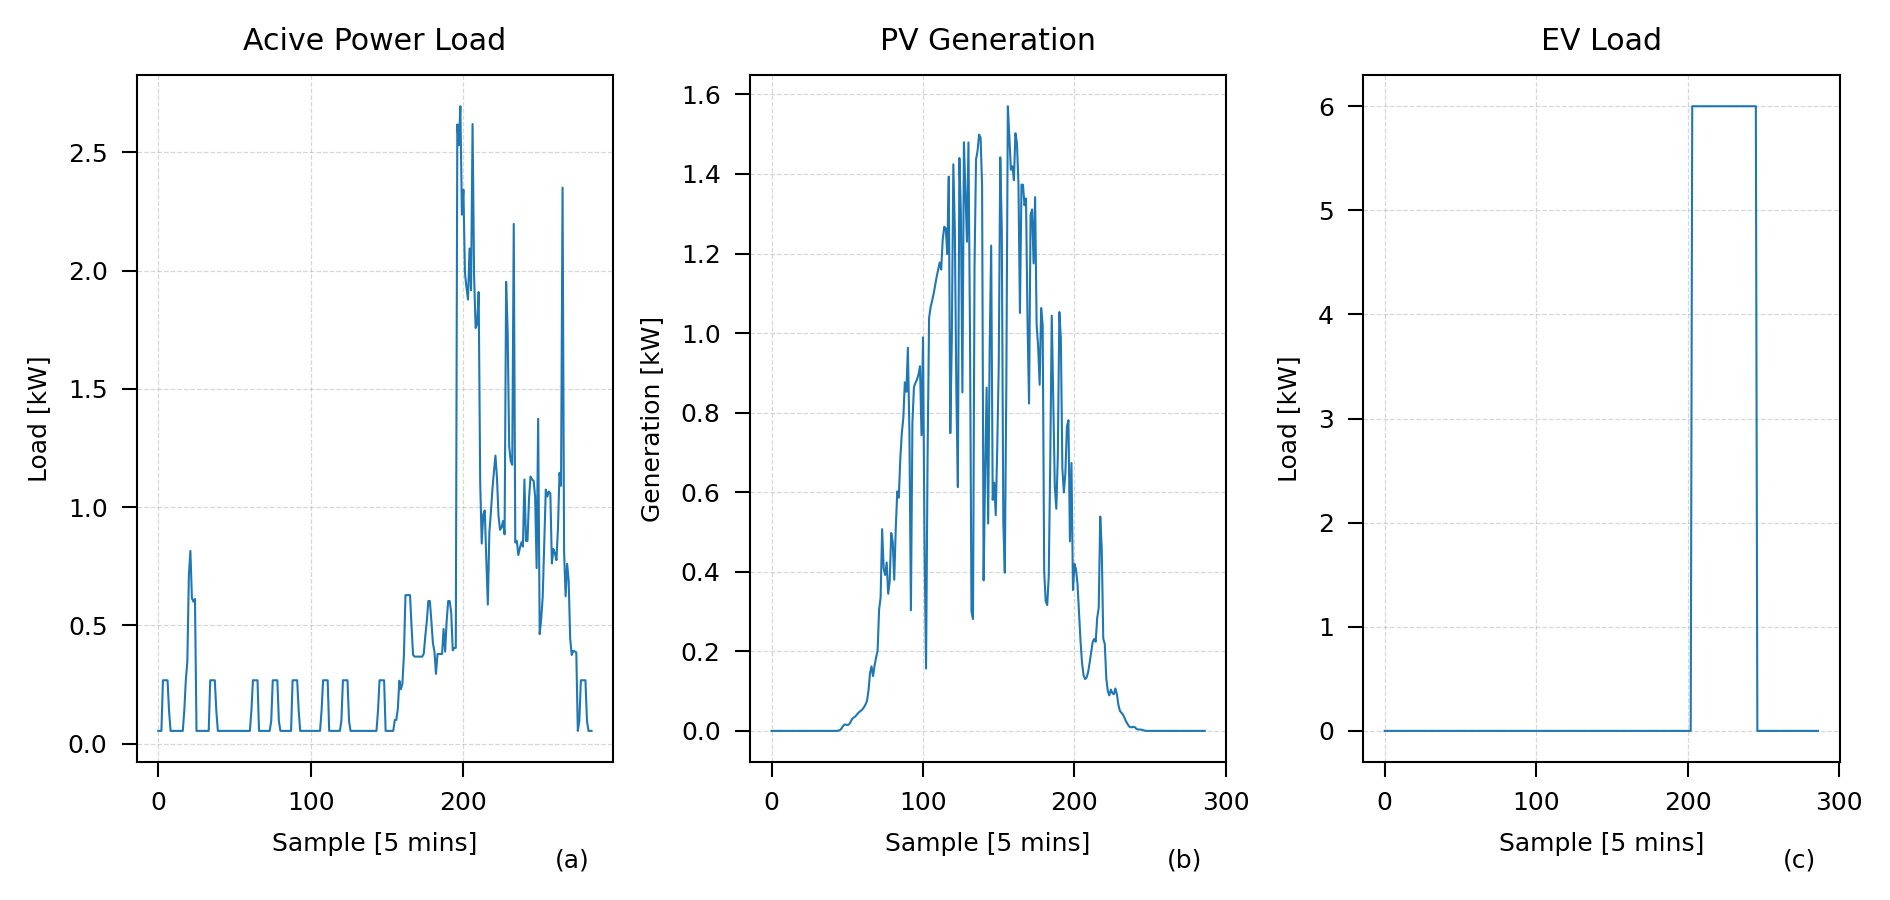

In [4]:
fig, ax = plt.subplots(1,3, figsize = (6.3,3))
ax[0].set_title("Acive Power Load")
ax[1].set_title("PV Generation")
ax[2].set_title("EV Load")


ax[0].set_ylabel("Load [kW]")
ax[1].set_ylabel("Generation [kW]")
ax[2].set_ylabel("Load [kW]")

sub_labels = ['(a)', '(b)', '(c)']
for i, label in enumerate(sub_labels):
    ax[i].set_xlabel("Sample [5 mins]")
    ax[i].text(0.95, -0.16, label, transform=ax[i].transAxes, horizontalalignment='right', verticalalignment='bottom')


for i in range(1):
    ax[0].plot(WinterLoads[i])
    ax[1].plot(PVLoads[i])
    ax[2].plot(EVLoads[i])
plt.tight_layout()
plt.savefig(base_path.joinpath("Images").joinpath("example_load.svg"))

# Settings

In [5]:
# Furthest node in order of net, feed
Nodes_Longest = [53, 31, 38, 67, 175, 137, 110, 113, 23, 93, 58, 97, 35, 19, 38, 24, 16, 17, 83, 20, 22, 4, 18, 155, 30, 36, 15, 23, 23, 116, 42, 71, 56, 50, 186, 61, 12, 20, 41, 297, 85, 3, 20, 20, 66, 22, 14, 5, 14, 6, 11, 5, 15, 3, 17, 61, 86, 156, 67, 89, 46, 16, 2, 173, 64, 1, 60, 43, 1, 1, 77, 96, 97, 138, 22, 65, 53, 39, 73, 67, 58, 180, 8, 76, 106, 99, 210, 107, 54, 22, 41, 34, 28, 19, 28, 20, 44, 49, 107, 61, 53, 47, 1, 26, 57, 19, 1, 21, 21, 60, 18, 27, 26, 13, 45, 26, 26, 37, 110, 39, 1, 88, 43, 56, 79, 11, 18, 12]


# Init OpenDSS

In [6]:
DSSText = dss.Text
DSSCircuit = dss.ActiveCircuit
DSSSolution = dss.ActiveCircuit.Solution
ControlQueue = dss.ActiveCircuit.CtrlQueue

# Function Definitions

In [7]:
def create_load_data(num_cust, num_days, data):
    customer_p, customer_q = [], []
    for _ in range(num_cust):
        cust_i_p,cust_i_q = [], []

        for _ in range(num_days):
            rand_int = random.randint(0,len(data)-1)
            cust_i_p.extend(data[rand_int])

            q = [i_load * math.tan(math.acos(random.uniform(0.9, 0.98))) for i_load in data[rand_int]]
            cust_i_q.extend(q)

        customer_p.append(cust_i_p)
        customer_q.append(cust_i_q)

    return customer_p, customer_q


def create_load_profiles(icust, iday, data_p, data_q, num_days):
    load_len = (len(data_p[0]))//num_days
    Zero_profile = [0]*load_len
    DSSCircuit.LoadShapes.New(f"customer_profile_{icust}")
    DSSCircuit.LoadShapes.Npts = load_len
    DSSCircuit.LoadShapes.MinInterval = 5
    DSSCircuit.LoadShapes.UseActual = 1
    DSSCircuit.LoadShapes.Pmult = data_p[icust][iday*load_len: (iday+1)*load_len]
    DSSCircuit.LoadShapes.Qmult = data_q[icust][iday*load_len: (iday+1)*load_len]

def set_load_profiles(cust, icust):
    DSSCircuit.SetActiveElement(f"load.{cust}")
    DSSCircuit.ActiveElement.Properties("daily").Val = f"customer_profile_{icust}"


def Initiate_variable(Num_Cust):
    cols = len(LoadProfile[0])
    rows = Num_Cust
    kW_monitors = np.zeros((rows,cols))
    kvar_monitors = np.zeros((rows,cols))
    voltages_monitors = np.zeros((rows,cols))
    df_kw = pd.DataFrame()
    df_kvar = pd.DataFrame()
    df_volt = pd.DataFrame()
    load_profiles_all = []
    pv_profiles_all = []
    ev_profiles_all = []
    random_profiles_all = []
    rand_cust_PV = []
    rand_cust_EV = []
    reactive_profiles_all = []
    return  (kW_monitors, kvar_monitors, voltages_monitors, df_kw, df_kvar,
             df_volt, load_profiles_all, ev_profiles_all,pv_profiles_all, random_profiles_all, rand_cust_PV,rand_cust_EV,reactive_profiles_all)


def Monitors_data():
    for icust, cust in enumerate(Loadname):
            DSSCircuit.SetActiveElement('load.%s' %(cust))
            kW_monitors[icust][itime] = DSSCircuit.ActiveElement.Powers[0]
            kvar_monitors[icust][itime]= DSSCircuit.ActiveElement.Powers[1]
            bus_name = DSSCircuit.ActiveElement.Properties('bus1').Val
            DSSCircuit.SetActiveBus(bus_name)
            voltages_monitors[icust][itime] = DSSCircuit.ActiveBus.puVmagAngle[0]


In [8]:
def PV_allocation(loads, PV_custs, data_PV, num_days):
    for customer in PV_custs:
        cust_pv_daily = []
        for _ in range(num_days):
            cust_pv_daily.extend(random.choice(data_PV))
        loads[customer] = [x - y for x,y in zip(loads[customer], cust_pv_daily)]
    return loads

def EV_allocation(loads, EV_custs, data_EV, num_days):
    for customer in EV_custs:
        cust_ev_daily = []
        for _ in range(num_days):
            cust_ev_daily.extend(random.choice(data_EV))
        loads[customer] = [x + y for x,y in zip(loads[customer], cust_ev_daily)]
    return loads


# Simulation

### Network

In [9]:
Network_Number = 1
Feeder_Number = 1

feeder_path = lv_models_path.joinpath(f"Network_{Network_Number}").joinpath(f"Feeder_{Feeder_Number}").joinpath("Master.txt")
coordinates_path = lv_models_path.joinpath(f"Network_{Network_Number}").joinpath(f"Feeder_{Feeder_Number}").joinpath("Bus_XY.dss")

### Loads

In [10]:
EV_Penetration = 80
PV_Penetration = 80
LoadProfile = SummerLoads
SIM_LENGTH = 1

In [11]:
DSSText.Command = 'Clear'
DSSText.Command = 'Set DefaultBaseFrequency=50'
DSSText.Command = 'New circuit.LVNet1circuit basekv=22.0 pu=1.00 angle=0 frequency=50 phases=3'

DSSText.Command = f'Compile {feeder_path.as_posix()}'

DSSText.Command = 'Set VoltageBases = [22.0, 0.400]'
DSSText.Command = 'calcvoltagebases'

Loadname = DSSCircuit.Loads.AllNames

# Init all load profile allocations
random.seed(42)
customer_p, customer_q = create_load_data(len(Loadname), SIM_LENGTH, LoadProfile)
# choose set of customers with EV and PV
rand_cust_EV = random.sample(range(len(Loadname)), round(len(Loadname)*(EV_Penetration/100)))
print("EV:", rand_cust_EV)
rand_cust_PV = random.sample(range(len(Loadname)), round(len(Loadname)*(PV_Penetration/100)))
print("PV:", rand_cust_PV)
#allocate PV and EV loads
customer_p = PV_allocation(customer_p, rand_cust_PV, PVLoads, SIM_LENGTH)
customer_p = EV_allocation(customer_p, rand_cust_EV, EVLoads, SIM_LENGTH)
for icust, cust in enumerate(Loadname):
    create_load_profiles(icust, 0, customer_p, customer_q, num_days=SIM_LENGTH)
    set_load_profiles(cust, icust)

n_steps = len(LoadProfile[0]) 
n_max_con = np.argmax(np.array(customer_p).sum(axis=0))
n_min_con = np.argmin(np.array(customer_p).sum(axis=0))
print(f"Minimum consumption step: {n_min_con}")
print(f"Maximum consumpiton step: {n_max_con}")

Voltages_Daily, kW_Daily, kvar_Daily = [], [], []

(kW_monitors, kvar_monitors, voltages_monitors, df_kw, df_kvar, df_volt,
load_profiles_all, ev_profiles_all, pv_profiles_all, random_profiles_all, rand_cust_PV,rand_cust_EV,reactive_profiles_all) = Initiate_variable(len(Loadname))
    
DSSText.Command = "New EnergyMeter.sub element=Line.LINE1 terminal=1"
DSSText.Command = 'Reset'
DSSText.Command = 'Set Mode=daily number=1 stepsize=5m'

for itime in range(n_max_con):
    DSSSolution.Solve()
    Monitors_data()

Voltages_Daily.append(voltages_monitors)
kW_Daily.append(kW_monitors)
kvar_Daily.append(kvar_monitors)

if DSSSolution.Converged:
    print('The Solution Converged Successfully')
else:
    print("The Solution Did Not Converge")

DSSText.Command = f"Buscoords  {coordinates_path}"

EV: [48, 42, 8, 3, 7, 38, 47, 43, 5, 50, 45, 24, 25, 6, 52, 11, 2, 44, 49, 28, 40, 21, 35, 15, 41, 29, 19, 23, 27, 30, 1, 9, 18, 53, 13, 12, 10, 33, 0, 46, 37, 22, 20, 4]
PV: [49, 33, 6, 9, 48, 18, 11, 52, 5, 54, 1, 35, 25, 40, 53, 8, 21, 0, 36, 20, 39, 51, 45, 24, 4, 37, 26, 28, 32, 47, 22, 50, 23, 12, 2, 29, 42, 31, 30, 15, 13, 19, 38, 44]
Minimum consumption step: 120
Maximum consumpiton step: 283
The Solution Converged Successfully


In [23]:
dss.Plotting.enable(show=False)
DSSText.Command = "plot scatter"
DSSText.Command = "set marktransformers=y"
ax = plt.gca()
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("")
ax.set_xticklabels([])
ax.set_yticklabels([])
dss.Plotting.enable(show=True)
plt.savefig(
    f"./Images/summer_peak_EV{EV_Penetration}_PV{PV_Penetration}.png",
    bbox_inches='tight'
)

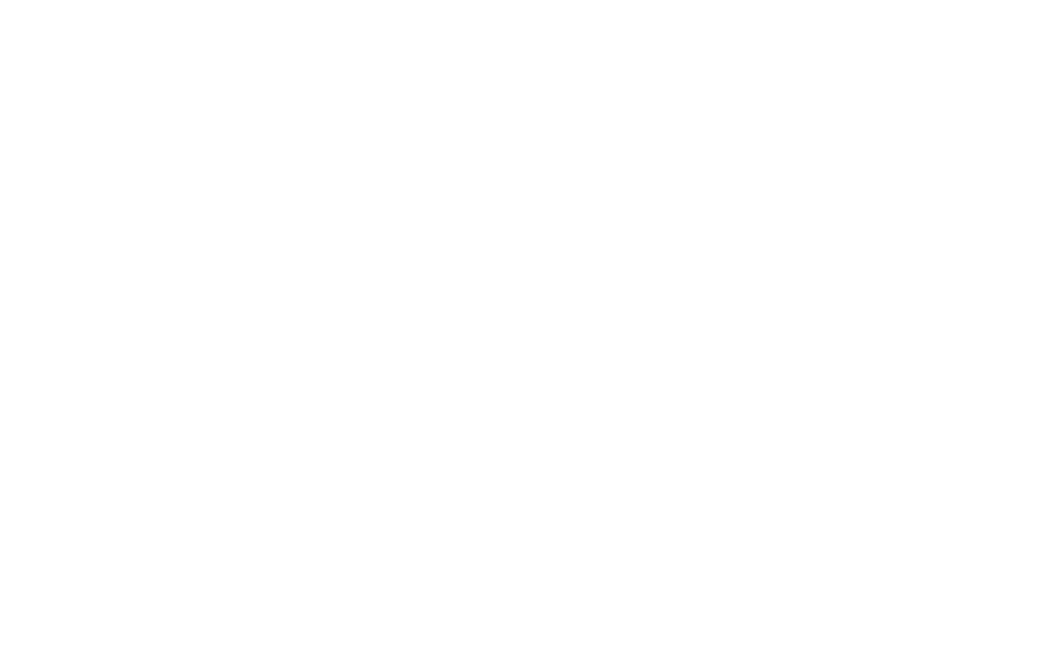

In [24]:
dss.Plotting.enable(show=True)
DSSText.Command = "plot profile phases=all"
plt.savefig(
    f"./Images/summer_peak_EV{EV_Penetration}_PV{PV_Penetration}_volt_profile.png",
    bbox_inches='tight'
)

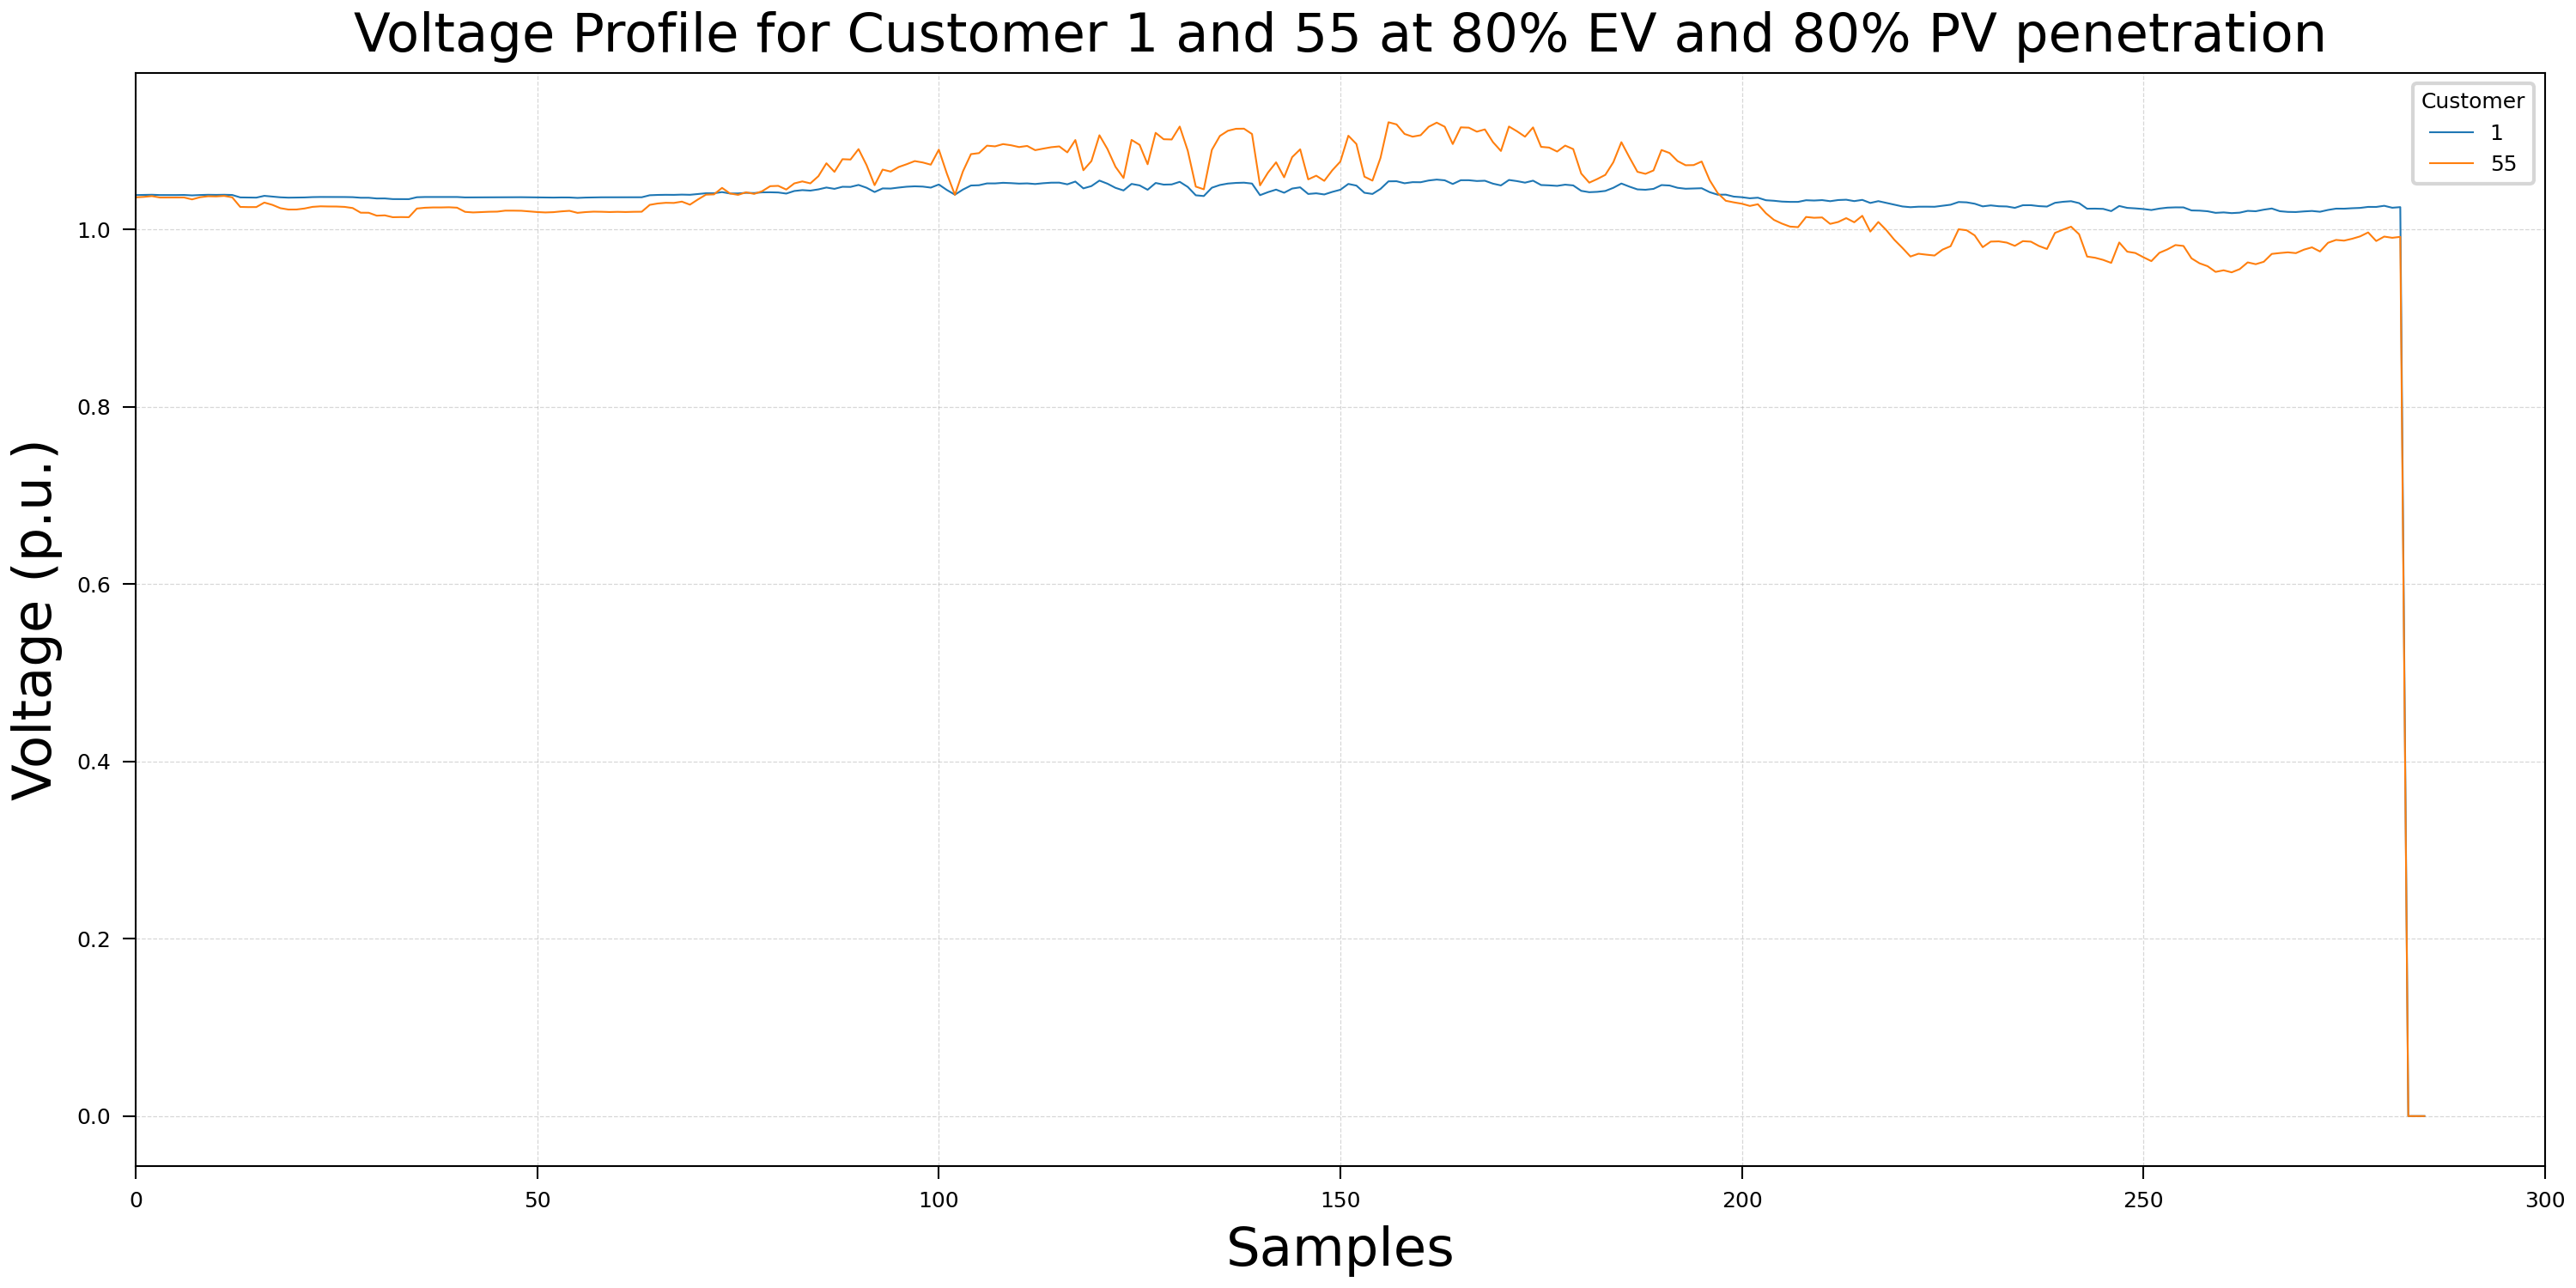

In [25]:
### Plotting Voltages###
fig, axes = plt.subplots(1,1, figsize = (10,5), layout="constrained")
axes.set_xlim(0,300)
plt.xlabel("Samples", fontsize = 15)
plt.ylabel('Voltage (p.u.)', fontsize = 15)
plt.title(f'Voltage Profile for Customer 1 and {55} at {EV_Penetration}% EV and {PV_Penetration}% PV penetration', fontsize = 15)

plt.plot(Voltages_Daily[0][0], label = "1")
plt.plot(Voltages_Daily[0][-1], label = f"{55}")


plt.legend(title = "Customer")

In [26]:
np.argmax(Voltages_Daily[0][-1])

np.int64(156)

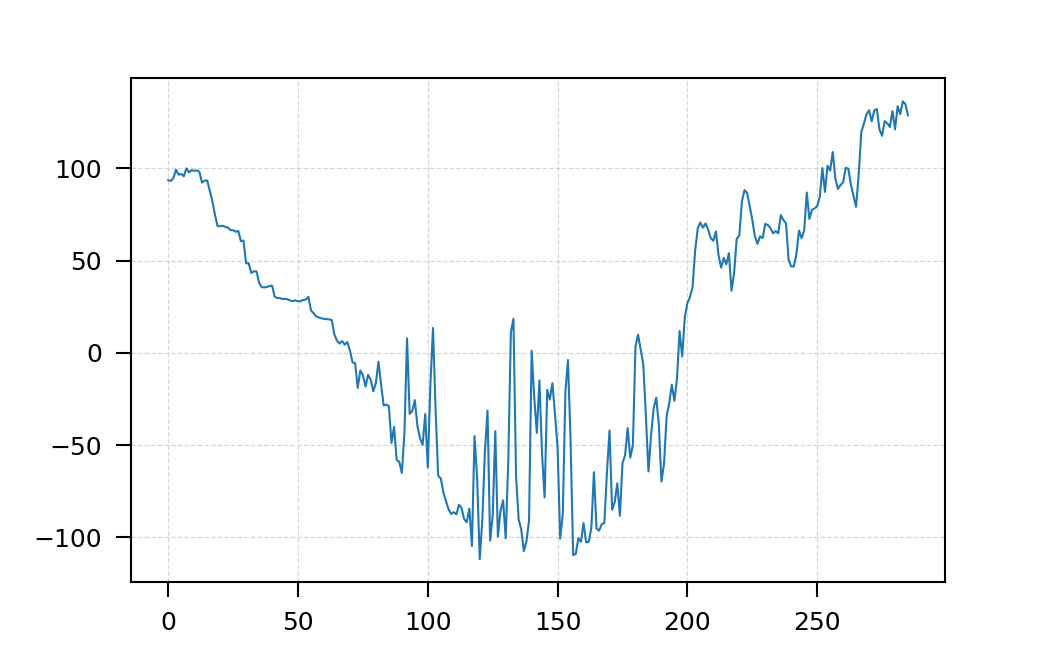

In [27]:
plt.figure()
plt.plot(np.array(customer_p).sum(axis=0))